# Final Integrated Static Multi-Head Model

## Joint American put pricing, continuation-value estimation, and exercise classification

**SoftUni Deep Learning Final Project**  
**Author:** Kamen Dimitrov  
**Notebook:** `08_final_multihead_model.ipynb`

---

This notebook integrates the strongest static-model ideas developed in Notebooks 04–06 into one jointly trained architecture. It does **not** merge the neural Longstaff–Schwartz policy from Notebook 07, because neural LSM consumes simulated paths and time-indexed states rather than one static contract vector.

The final static model shares one representation of the option state and produces four outputs:

1. a non-negative residual above a financial pricing floor;
2. a direct normalized American put price;
3. a normalized continuation value;
4. an exercise-versus-continuation logit.

The constrained residual head is designated as the authoritative pricing output. The remaining heads are auxiliary tasks and internal diagnostic signals.

## Research objective

The main question is:

> Can joint learning of price, continuation value, and exercise policy improve predictive accuracy and internal financial coherence relative to separately trained static neural networks?

The design follows the general multi-task-learning proposition that related objectives may benefit from a shared representation when their information is complementary. In this project, however, the model is not accepted merely because it has more outputs. It must demonstrate measurable value through:

- lower pricing errors;
- better exercise-boundary behavior;
- accurate continuation values;
- fewer contradictory outputs;
- acceptable out-of-domain performance;
- inference speed that remains competitive with simpler static networks.

The final cross-model conclusion is deferred to Notebook 09.

## Financial reconstruction

Let the normalized European and intrinsic values be

$$
\widetilde V_E=\frac{V_E}{K},
\qquad
\widetilde I=\frac{\max(K-S,0)}{K}.
$$

The financial floor is

$$
\widetilde F=\max(\widetilde V_E,\widetilde I).
$$

The residual head predicts

$$
\widehat R_F=\operatorname{Softplus}(h_R(z)),
$$

and the authoritative price is reconstructed as

$$
\widehat V_A^{\,constrained}
=\widetilde F+\widehat R_F.
$$

This guarantees non-negativity and both lower bounds by construction. The direct-price head remains unconstrained relative to those two floors except for a non-negative output transformation, making it useful as an internal ablation.

## Two exercise-decision paths

The exercise head produces

$$
\widehat p_E=\sigma(\ell_E).
$$

The continuation head creates a second implied decision path:

$$
\widehat p_C
=
\sigma\left(\kappa\left[\widetilde I-\widehat C\right]\right).
$$

If the model is internally coherent, these two probabilities should agree. Their disagreement is penalized during training and measured explicitly after training.

# 1. Environment and reproducibility configuration

The default notebook profile is a small executable smoke experiment. Set `SMOKE_MODE = False` only after the 1.45 million-observation production dataset has been generated.

In [1]:
from pathlib import Path
import json
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

SMOKE_MODE = True
RUN_TRAINING = True
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "final_multihead"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Device:       {DEVICE}")
print(f"Smoke mode:   {SMOKE_MODE}")

Project root: /storage/deep_learning_american_option_pricing
Device:       cuda
Smoke mode:   True


# 2. Imports from the reusable project modules

The notebook contains research orchestration and interpretation. Model, loss, target, training, and evaluation logic remains in `src/`.

In [2]:
from src.data.multihead_targets import add_integrated_targets
from src.data.production_generation import (
    CORE_RANGES,
    ProductionDatasetConfig,
    build_priced_frame,
    sample_parameter_chunk,
)
from src.data.torch_datasets import (
    FEATURE_COLUMNS,
    IntegratedMultiHeadDataset,
    LoaderConfig,
    create_integrated_multihead_loader,
    fit_feature_scaler,
    read_parquet_components,
    save_feature_scaler,
)
from src.evaluation.classification_metrics import (
    binary_classification_metrics,
    confusion_matrix_frame,
)
from src.evaluation.integrated_model_comparison import (
    build_integrated_ablation_table,
    evaluate_integrated_prediction_frame,
    select_validation_configuration,
)
from src.evaluation.internal_consistency import (
    contradictory_output_flags,
    internal_consistency_metrics,
)
from src.evaluation.regression_metrics import regression_metrics
from src.models.integrated_multihead_pricer import (
    IntegratedAmericanPutMultiHeadMLP,
    IntegratedMultiHeadConfig,
    copy_compatible_backbone_weights,
)
from src.training.multihead_losses import (
    IntegratedMultiHeadLoss,
    multihead_loss_preset,
)
from src.training.multihead_loops import (
    IntegratedTrainingConfig,
    fit_integrated_multihead_model,
    predict_integrated_multihead_model,
)
from src.training.multitask_losses import calculate_positive_class_weight

# 3. Load the frozen production splits

The integrated model reuses the exact core and boundary observations from the previous static experiments. It does not create a new random split.

When production files are unavailable and smoke mode is enabled, a deterministic miniature CRR dataset is generated only to validate the full execution path. Smoke results are not academic evidence and must not be used in Notebook 09.

In [3]:
RAW_COLUMNS = [
    "sample_id",
    "split",
    *FEATURE_COLUMNS,
    "strike",
    "intrinsic_value",
    "continuation_value",
    "european_price",
    "american_price",
    "exercise_now",
]

production_paths = [
    PROJECT_ROOT / "data" / "generated" / "american_put_core.parquet",
    PROJECT_ROOT / "data" / "generated" / "american_put_boundary.parquet",
]
production_paths = [path for path in production_paths if path.exists()]

if production_paths:
    row_limits = {
        "train": 8_000 if SMOKE_MODE else None,
        "validation": 2_000 if SMOKE_MODE else None,
        "test": 2_000 if SMOKE_MODE else None,
    }
    split_frames = {
        split: read_parquet_components(
            production_paths,
            columns=RAW_COLUMNS,
            split=split,
            row_limit=limit,
        )
        for split, limit in row_limits.items()
    }
else:
    if not SMOKE_MODE:
        raise FileNotFoundError(
            "Production dataset not found. Run scripts/generate_production_dataset.py first."
        )
    smoke_config = ProductionDatasetConfig(
        core_observations=12_000,
        boundary_observations=3_000,
        ood_observations_per_set=500,
        tree_steps=50,
        chunk_size=12_000,
        seed=SEED,
    )
    parameters = sample_parameter_chunk(
        n_samples=12_000,
        ranges=CORE_RANGES,
        seed=SEED,
        strike=smoke_config.strike,
    )
    smoke_frame = build_priced_frame(
        parameters=parameters,
        sample_ids=np.arange(12_000, dtype=np.int64),
        component="smoke",
        tree_steps=smoke_config.tree_steps,
        split_eligible=True,
        config=smoke_config,
    )
    split_frames = {
        split: smoke_frame.loc[smoke_frame["split"] == split].copy()
        for split in ("train", "validation", "test")
    }

for split, frame in split_frames.items():
    add_integrated_targets(frame, copy=False)

pd.DataFrame(
    {
        "rows": {name: len(frame) for name, frame in split_frames.items()},
        "exercise_rate": {
            name: frame["exercise_now"].mean()
            for name, frame in split_frames.items()
        },
    }
)

,rows,exercise_rate
train,8000,0.106125
validation,2000,0.092000
test,2000,0.096500


The split summary is a leakage-control checkpoint. The model-selection configurations use training and validation observations only. The final test set is reserved until one configuration has been selected.

# 4. Target audit

The four learned targets are:

- normalized floor residual;
- normalized American price;
- normalized continuation value;
- binary exercise decision.

The residual and continuation targets are strongly regime-dependent, so their distributions must be inspected before training.

In [4]:
target_columns = [
    "normalized_floor_residual",
    "normalized_american_price",
    "normalized_continuation_value",
    "exercise_now",
]

split_frames["train"][target_columns].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
normalized_floor_residual,8000.0,0.003180,0.005858,0.0,0.000000e+00,0.000000,0.000453,0.015805,0.027816,0.056245
normalized_american_price,8000.0,0.202185,0.153996,0.0,1.492529e-11,0.000296,0.186919,0.472916,0.512666,0.594146
normalized_continuation_value,8000.0,0.202166,0.153983,0.0,9.807296e-12,0.000293,0.186919,0.472829,0.512666,0.594146


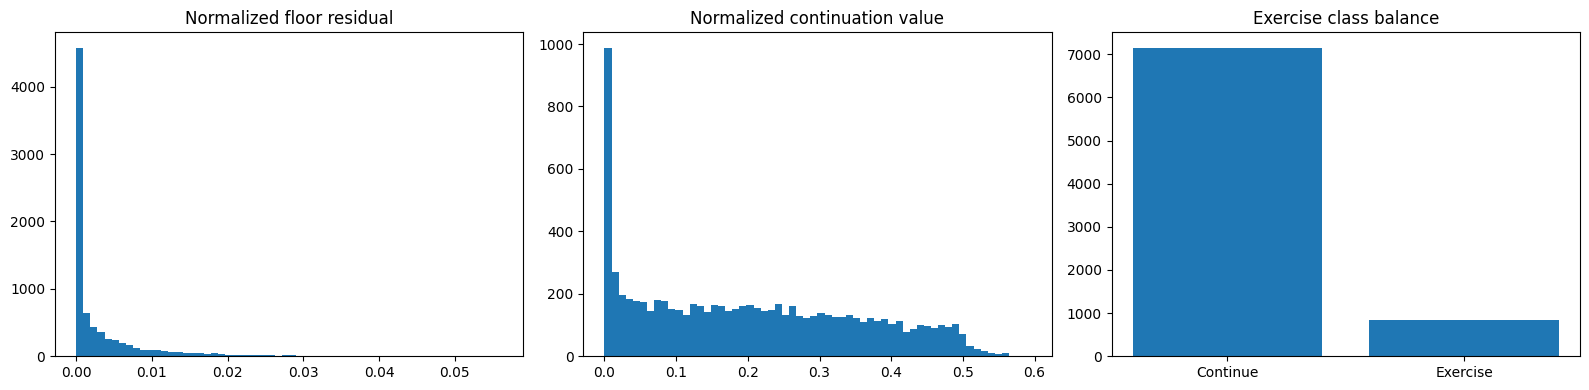

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(split_frames["train"]["normalized_floor_residual"], bins=60)
axes[0].set_title("Normalized floor residual")
axes[1].hist(split_frames["train"]["normalized_continuation_value"], bins=60)
axes[1].set_title("Normalized continuation value")
axes[2].bar(
    ["Continue", "Exercise"],
    split_frames["train"]["exercise_now"].value_counts().reindex([False, True], fill_value=0),
)
axes[2].set_title("Exercise class balance")
plt.tight_layout()
plt.show()

A near-zero residual concentration can make aggregate loss misleading. The continuation and exercise heads provide auxiliary supervision intended to prevent the shared backbone from optimizing only for the dominant smooth pricing region.

# 5. Training-only scaling and PyTorch datasets

The feature scaler and positive-class weight are fitted exclusively on the training split.

In [6]:
scaler = fit_feature_scaler(split_frames["train"], feature_columns=FEATURE_COLUMNS)
save_feature_scaler(scaler, ARTIFACT_DIR / "feature_scaler.joblib")
positive_class_weight = calculate_positive_class_weight(
    split_frames["train"]["exercise_now"],
    maximum_weight=50.0,
)

loader_config = LoaderConfig(
    batch_size=512 if SMOKE_MODE else 1024,
    num_workers=0,
    pin_memory=True,
    seed=SEED,
)

datasets = {
    name: IntegratedMultiHeadDataset(frame, scaler=scaler)
    for name, frame in split_frames.items()
}
loaders = {
    "train": create_integrated_multihead_loader(
        datasets["train"],
        config=loader_config,
        shuffle=True,
        drop_last=True,
    ),
    "validation": create_integrated_multihead_loader(
        datasets["validation"],
        config=loader_config,
        shuffle=False,
    ),
    "test": create_integrated_multihead_loader(
        datasets["test"],
        config=loader_config,
        shuffle=False,
    ),
}

batch = next(iter(loaders["train"]))
{
    key: tuple(value.shape) if isinstance(value, torch.Tensor) else type(value).__name__
    for key, value in batch.items()
}

{'features': (512, 5),
 'floor_residual_target': (512, 1),
 'direct_price_target': (512, 1),
 'continuation_target': (512, 1),
 'exercise_target': (512, 1),
 'normalized_european': (512, 1),
 'normalized_intrinsic': (512, 1),
 'row_id': (512,)}

# 6. Architecture and parameter count

The default scratch model uses a larger shared backbone than the earlier static networks. A separate Step 6-compatible configuration is available for the warm-start experiment.

In [7]:
large_config = IntegratedMultiHeadConfig()
step6_compatible_config = IntegratedMultiHeadConfig.step6_compatible()

architecture_table = pd.DataFrame(
    [
        {
            "architecture": "large_scratch",
            "shared_hidden_sizes": large_config.shared_hidden_sizes,
            "parameters": IntegratedAmericanPutMultiHeadMLP(large_config).trainable_parameter_count,
        },
        {
            "architecture": "step6_compatible",
            "shared_hidden_sizes": step6_compatible_config.shared_hidden_sizes,
            "parameters": IntegratedAmericanPutMultiHeadMLP(step6_compatible_config).trainable_parameter_count,
        },
    ]
)
architecture_table

,architecture,shared_hidden_sizes,parameters
0,large_scratch,"(192, 192, 96)",76324
1,step6_compatible,"(128, 128, 64)",34500


The warm-start model is not treated as a clean capacity comparison with the larger scratch model. It is a convergence ablation that asks whether previously learned exercise-related features reduce training time or improve validation performance.

# 7. Predefined multi-objective loss configurations

To avoid unrestricted post-hoc tuning, only three configurations are considered:

- **balanced** — comparable emphasis across related tasks;
- **pricing-focused** — greater weight on constrained and direct price errors;
- **decision-focused** — greater weight on continuation and exercise behavior.

In [8]:
loss_configurations = {
    name: multihead_loss_preset(name)
    for name in ("balanced", "pricing_focused", "decision_focused")
}

pd.DataFrame(
    {
        name: config.weights.to_dict()
        for name, config in loss_configurations.items()
    }
).T

,floor_residual,direct_price,continuation,exercise,price_consistency,exercise_consistency
balanced,1.00,0.50,0.50,0.50,0.10,0.10
pricing_focused,1.50,1.00,0.25,0.25,0.20,0.05
decision_focused,0.75,0.25,1.00,1.00,0.05,0.25


# 8. Scratch-training ablation

Each configuration is trained from the same random seed and evaluated on the validation split. Smoke mode uses three epochs; the final run uses early stopping with a maximum of 100 epochs.

In [9]:
training_config = IntegratedTrainingConfig(
    epochs=3 if SMOKE_MODE else 100,
    early_stopping_patience=3 if SMOKE_MODE else 12,
    scheduler_patience=2 if SMOKE_MODE else 4,
    mixed_precision=DEVICE.type == "cuda",
    seed=SEED,
)

trained_models = {}
histories = {}
validation_predictions = {}

if RUN_TRAINING:
    for name, loss_config in loss_configurations.items():
        model = IntegratedAmericanPutMultiHeadMLP(large_config)
        loss_fn = IntegratedMultiHeadLoss(
            config=loss_config,
            positive_class_weight=positive_class_weight,
        )
        checkpoint_path = ARTIFACT_DIR / f"best_{name}.pt"
        history = fit_integrated_multihead_model(
            model,
            loaders["train"],
            loaders["validation"],
            loss_fn=loss_fn,
            config=training_config,
            device=DEVICE,
            checkpoint_path=checkpoint_path,
            model_config=large_config.to_dict(),
        )
        predictions = predict_integrated_multihead_model(
            model,
            loaders["validation"],
            device=DEVICE,
            decision_sharpness=loss_config.decision_sharpness,
        )
        trained_models[name] = model
        histories[name] = history
        validation_predictions[name] = predictions
else:
    raise RuntimeError("Set RUN_TRAINING=True or add artifact-loading logic for this run.")

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, history in histories.items():
    ax.plot(history["epoch"], history["validation_loss"], label=name)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation multi-objective loss")
ax.set_title("Validation loss by predefined configuration")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

# 9. Validation selection

The selection rule is fixed before test evaluation:

1. minimize constrained-price RMSE;
2. among ties, maximize exercise F1;
3. among remaining ties, minimize disagreement between the two exercise paths.

In [ ]:
validation_table = build_integrated_ablation_table(validation_predictions)
selection = select_validation_configuration(validation_table)
validation_table[[
    "constrained_rmse",
    "direct_rmse",
    "continuation_rmse",
    "exercise_f1",
    "consistency_decision_disagreement_rate",
    "consistency_direct_constrained_mae",
]].sort_values("constrained_rmse")

In [ ]:
selection

The test set is not used in the selection logic. This prevents the final static model from being chosen retrospectively based on its reported test performance.

# 10. Optional Step 6 warm-start experiment

If a Step 6 checkpoint is available, compatible backbone parameters are copied into the Step 6-compatible architecture. Only exact name-and-shape matches are accepted, and the copy operation produces an audit report.

In [ ]:
step6_checkpoint = PROJECT_ROOT / "artifacts" / "multitask_model" / "best_multitask_pricer.pt"
warm_start_result = None
warm_start_history = None

if step6_checkpoint.exists() and RUN_TRAINING:
    checkpoint = torch.load(step6_checkpoint, map_location="cpu", weights_only=False)
    warm_model = IntegratedAmericanPutMultiHeadMLP(step6_compatible_config)
    warm_start_result = copy_compatible_backbone_weights(
        warm_model,
        checkpoint["model_state_dict"],
    )
    selected_name = selection["configuration"]
    selected_loss_config = loss_configurations[selected_name]
    warm_loss_fn = IntegratedMultiHeadLoss(
        config=selected_loss_config,
        positive_class_weight=positive_class_weight,
    )
    warm_start_history = fit_integrated_multihead_model(
        warm_model,
        loaders["train"],
        loaders["validation"],
        loss_fn=warm_loss_fn,
        config=training_config,
        device=DEVICE,
        checkpoint_path=ARTIFACT_DIR / "best_warm_start.pt",
        model_config=step6_compatible_config.to_dict(),
        warm_start_report=warm_start_result,
    )
    warm_predictions = predict_integrated_multihead_model(
        warm_model,
        loaders["validation"],
        device=DEVICE,
        decision_sharpness=selected_loss_config.decision_sharpness,
    )
    validation_predictions["warm_start"] = warm_predictions
else:
    print("Step 6 checkpoint not found; warm-start ablation skipped.")

warm_start_result

# 11. Final in-domain test evaluation

The selected validation configuration is now evaluated once on the held-out test split.

In [ ]:
selected_name = selection["configuration"]
selected_model = trained_models[selected_name]
selected_loss_config = loss_configurations[selected_name]

test_predictions = predict_integrated_multihead_model(
    selected_model,
    loaders["test"],
    device=DEVICE,
    decision_sharpness=selected_loss_config.decision_sharpness,
)
test_metrics = evaluate_integrated_prediction_frame(test_predictions)

pd.Series({
    "Constrained price RMSE": test_metrics["constrained_rmse"],
    "Constrained price MAE": test_metrics["constrained_mae"],
    "Direct head RMSE": test_metrics["direct_rmse"],
    "Continuation RMSE": test_metrics["continuation_rmse"],
    "Exercise F1": test_metrics["exercise_f1"],
    "Exercise balanced accuracy": test_metrics["exercise_balanced_accuracy"],
    "Decision disagreement rate": test_metrics["consistency_decision_disagreement_rate"],
})

# 12. Pricing-head comparison

The constrained and direct heads share the same backbone but embody different financial assumptions. The direct head can reveal whether the hard lower-bound reconstruction improves or distorts price accuracy.

In [ ]:
pricing_comparison = pd.DataFrame(
    [
        {
            "head": "Constrained residual",
            **regression_metrics(
                test_predictions["true_normalized_american_price"],
                test_predictions["predicted_normalized_american_price"],
            ),
        },
        {
            "head": "Direct price",
            **regression_metrics(
                test_predictions["true_normalized_american_price"],
                test_predictions["predicted_direct_normalized_american_price"],
            ),
        },
    ]
).set_index("head")
pricing_comparison

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(
    test_predictions["true_normalized_american_price"],
    test_predictions["predicted_normalized_american_price"],
    s=8,
    alpha=0.35,
)
limits = [
    min(test_predictions["true_normalized_american_price"].min(), test_predictions["predicted_normalized_american_price"].min()),
    max(test_predictions["true_normalized_american_price"].max(), test_predictions["predicted_normalized_american_price"].max()),
]
plt.plot(limits, limits, linestyle="--")
plt.xlabel("CRR normalized American price")
plt.ylabel("Integrated constrained prediction")
plt.title("Integrated model: actual versus predicted price")
plt.grid(alpha=0.25)
plt.show()

# 13. Continuation-value evaluation

Continuation value is not merely an auxiliary numerical target. It is the economic quantity against which immediate exercise is compared.

In [ ]:
continuation_metrics = regression_metrics(
    test_predictions["true_normalized_continuation_value"],
    test_predictions["predicted_normalized_continuation_value"],
)
pd.Series(continuation_metrics)

# 14. Exercise classification and confusion matrix

Classification performance is evaluated independently from price error. A low pricing RMSE does not guarantee correct stopping decisions.

In [ ]:
exercise_metrics = binary_classification_metrics(
    test_predictions["exercise_target"],
    test_predictions["exercise_probability"],
)
exercise_confusion = confusion_matrix_frame(
    test_predictions["exercise_target"],
    test_predictions["exercise_probability"],
)
pd.Series(exercise_metrics), exercise_confusion

# 15. Internal consistency

The final model contains multiple routes to related financial quantities. These outputs can contradict one another even when each head performs well in isolation. The following report measures:

- direct-versus-constrained price disagreement;
- classification-versus-continuation decision disagreement;
- lower-bound violations by each price head;
- residual reconstruction identity.

In [ ]:
consistency_metrics = internal_consistency_metrics(test_predictions)
consistency_flags = contradictory_output_flags(test_predictions)

pd.Series(consistency_metrics), consistency_flags.mean().sort_values(ascending=False)

The constrained head should have zero European, intrinsic, and non-negativity violations by construction. This does not guarantee monotonicity in spot, strike, volatility, or maturity; those remain empirical evaluation questions for Notebook 09.

# 16. Boundary-focused analysis

Observations are grouped by the absolute normalized difference between intrinsic and continuation value. The narrowest bands represent the most difficult optimal-stopping region.

In [ ]:
test_analysis = split_frames["test"].loc[
    :,
    ["sample_id", "boundary_distance_normalized", "moneyness", "time_to_maturity", "volatility"],
].merge(test_predictions, on="sample_id", validate="one_to_one")

test_analysis["boundary_band"] = pd.cut(
    test_analysis["boundary_distance_normalized"],
    bins=[-np.inf, 0.001, 0.005, 0.01, np.inf],
    labels=["≤0.001", "0.001–0.005", "0.005–0.010", ">0.010"],
)

boundary_rows = []
for band, group in test_analysis.groupby("boundary_band", observed=True):
    price = regression_metrics(
        group["true_normalized_american_price"],
        group["predicted_normalized_american_price"],
    )
    classification = binary_classification_metrics(
        group["exercise_target"],
        group["exercise_probability"],
    )
    boundary_rows.append({
        "boundary_band": band,
        "observations": len(group),
        "price_mae": price["mae"],
        "price_rmse": price["rmse"],
        "exercise_f1": classification["f1"],
        "balanced_accuracy": classification["balanced_accuracy"],
    })

pd.DataFrame(boundary_rows)

# 17. Optional out-of-domain evaluation

OOD evaluation uses the same scaler fitted on in-domain training data. No OOD observations are used to update the model or preprocessing.

In [ ]:
ood_paths = sorted((PROJECT_ROOT / "data" / "generated").glob("american_put_ood_*.parquet"))
ood_results = []

for path in ood_paths:
    frame = pd.read_parquet(path, columns=RAW_COLUMNS)
    if SMOKE_MODE:
        frame = frame.head(2_000).copy()
    add_integrated_targets(frame, copy=False)
    dataset = IntegratedMultiHeadDataset(frame, scaler=scaler)
    loader = create_integrated_multihead_loader(
        dataset,
        config=loader_config,
        shuffle=False,
    )
    predictions = predict_integrated_multihead_model(
        selected_model,
        loader,
        device=DEVICE,
        decision_sharpness=selected_loss_config.decision_sharpness,
    )
    metrics = evaluate_integrated_prediction_frame(predictions)
    ood_results.append({
        "component": path.stem,
        "constrained_rmse": metrics["constrained_rmse"],
        "continuation_rmse": metrics["continuation_rmse"],
        "exercise_f1": metrics["exercise_f1"],
        "decision_disagreement_rate": metrics["consistency_decision_disagreement_rate"],
    })

pd.DataFrame(ood_results)

If no OOD files are displayed, the production generation pipeline has not yet been completed in the current environment. Notebook 09 must not make an OOD conclusion without those results.

# 18. Inference-speed benchmark

The integrated model performs more head computations than the earlier static models, but all heads reuse one backbone. The benchmark measures end-to-end batched inference rather than only one matrix multiplication.

In [ ]:
selected_model.eval().to(DEVICE)
benchmark_features = torch.randn(100_000 if not SMOKE_MODE else 10_000, 5, device=DEVICE)
benchmark_european = torch.rand(len(benchmark_features), 1, device=DEVICE) * 0.2
benchmark_intrinsic = torch.rand(len(benchmark_features), 1, device=DEVICE) * 0.2

if DEVICE.type == "cuda":
    torch.cuda.synchronize()
started = time.perf_counter()
with torch.inference_mode():
    raw = selected_model(benchmark_features)
    _ = raw["floor_residual"] + torch.maximum(benchmark_european, benchmark_intrinsic)
if DEVICE.type == "cuda":
    torch.cuda.synchronize()
elapsed = time.perf_counter() - started

pd.Series({
    "observations": len(benchmark_features),
    "seconds": elapsed,
    "observations_per_second": len(benchmark_features) / elapsed,
    "device": str(DEVICE),
})

# 19. Save selected artifacts

The selected checkpoint is already saved during training. This section writes the validation ablation, test predictions, metrics, and an explicit declaration of the authoritative output.

In [ ]:
def save_frame(frame: pd.DataFrame, path: Path) -> Path:
    try:
        frame.to_parquet(path, index=False)
        return path
    except ImportError:
        fallback = path.with_suffix(".csv")
        frame.to_csv(fallback, index=False)
        return fallback

validation_table.to_csv(ARTIFACT_DIR / "validation_ablation.csv")
save_frame(test_predictions, ARTIFACT_DIR / "test_predictions.parquet")
(ARTIFACT_DIR / "loss_config.json").write_text(
    json.dumps(selected_loss_config.to_dict(), indent=2),
    encoding="utf-8",
)
(ARTIFACT_DIR / "test_metrics.json").write_text(
    json.dumps(test_metrics, indent=2),
    encoding="utf-8",
)
(ARTIFACT_DIR / "selection.json").write_text(
    json.dumps({
        **selection,
        "authoritative_price_output": "constrained_price",
    }, indent=2),
    encoding="utf-8",
)

sorted(path.name for path in ARTIFACT_DIR.iterdir())

# 20. Interpretation framework

The final model should not be declared superior simply because it is more complex. The evidence must distinguish among several possible outcomes:

- **Joint-learning benefit:** constrained price, continuation, and boundary metrics improve together.
- **Pricing-only benefit:** price improves while continuation or exercise performance deteriorates.
- **Decision-only benefit:** stopping decisions improve without material pricing improvement.
- **Internal-coherence benefit:** predictive metrics remain similar but contradictory outputs decline.
- **Negative result:** the additional heads do not justify their parameter and training cost.

A negative or mixed result remains academically useful because the separately trained models provide controlled ablations.

# 21. Relationship with Neural Longstaff–Schwartz

The integrated model and neural LSM solve related but distinct problems:

| Model family | Input | Learning problem | Primary output |
|---|---|---|---|
| Integrated static model | One contract parameter vector | Supervised approximation of CRR labels | Fast price and root exercise diagnostics |
| Neural LSM | Simulated path states over exercise dates | Backward-induction continuation policy | Path-dependent stopping policy and Monte Carlo price |

They are therefore compared in Notebook 09 rather than combined into one architecture.

# 22. Limitations

- The four heads share the same synthetic CRR labels and are not independent sources of truth.
- Continuation values are root-node quantities produced by the selected finite tree.
- Consistency losses can encourage agreement even when both heads are wrong.
- Hard lower-bound reconstruction does not enforce all no-arbitrage shape conditions.
- Loss weights remain design choices, even though the candidate set is predefined.
- Warm-start and scratch architectures differ in capacity unless an explicitly matched architecture is used.
- Strong in-domain performance does not establish reliable OOD behavior or real-market validity.

# 23. References used in this notebook

Caruana, R. (1997). Multitask learning. *Machine Learning, 28*, 41–75.

Ding, L., Lu, E., & Cheung, K. (2025). *Deep learning option pricing with market implied volatility surfaces*. arXiv:2509.05911.

Ke, A., & Yang, A. (2019). *Option pricing with deep learning*. CS230, Stanford University.

Longstaff, F. A., & Schwartz, E. S. (2001). Valuing American options by simulation: A simple least-squares approach. *Review of Financial Studies, 14*(1), 113–147.

Pimentel, R., et al. (2026). Option pricing with deep learning: A long short-term memory approach. *Decisions in Economics and Finance, 49*, 155–186.

Pu, V. R. H. (2021). *Pricing options using deep neural networks from a practical perspective* [Master’s thesis, Imperial College London].

# 24. Development checkpoint

Notebook 08 produces the final integrated static model and its complete analytical outputs. Notebook 09 will:

1. load all final checkpoints and result artifacts;
2. compare static, CRR, classical LSM, and neural LSM methods on aligned evaluation sets;
3. decide H1–H6;
4. complete the literature synthesis;
5. write the final discussion, limitations, and conclusion.